In [1]:
!pip install gdown

## EDA SESI 1

In [2]:
import gdown

file_id = "1BRrvsIDOk9soBlsKwWqMsS79oVBQgZtf"

gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    "dataset.zip",
    quiet=False
)

Downloading...
From (original): https://drive.google.com/uc?id=1BRrvsIDOk9soBlsKwWqMsS79oVBQgZtf
From (redirected): https://drive.google.com/uc?id=1BRrvsIDOk9soBlsKwWqMsS79oVBQgZtf&confirm=t&uuid=30bd1d31-0b48-4ce4-8c5c-e5e71703b9d9
To: /content/dataset.zip
100%|██████████| 43.9M/43.9M [00:00<00:00, 187MB/s]


'dataset.zip'

### Ekstraksi

In [3]:
import zipfile

with zipfile.ZipFile("dataset.zip", 'r') as z:
    print(z.namelist())

['orders.csv', 'order_items.csv', 'customers.csv', 'sellers.csv', 'products.csv', 'order_reviews.csv', 'order_payments.csv', 'geolocation.csv', 'category_translation.csv', 'mql.csv', 'closed_deals.csv']


### Data Profiling

In [4]:
import zipfile
import pandas as pd

datasets = {}

with zipfile.ZipFile("dataset.zip") as z:
    for file in z.namelist():
        with z.open(file) as f:
            df = pd.read_csv(f)
            datasets[file] = df

            print("="*70)
            print(f"DATASET : {file}")
            print("="*70)

            print("Shape:")
            print(df.shape)

            print("\nColumns:")
            print(df.columns.tolist())

            print("\nDtypes:")
            print(df.dtypes)

            print("\nMissing Values:")
            print(df.isnull().sum())

            print("\nDuplicate Rows:")
            print(df.duplicated().sum())

            print("\nMemory Usage (MB):")
            print(round(df.memory_usage(deep=True).sum()/1024**2,2))

DATASET : orders.csv
Shape:
(99441, 8)

Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Dtypes:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Missing Values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Duplicate Rows:
0

Memory Usage (MB):
52.94
DATASET : order_items.csv
Shape:
(1126

### Pemisahan Dataset ke Variabel Spesifik & Verifikasi Akhir


In [ ]:
orders = datasets.get("orders.csv")
order_items = datasets.get("order_items.csv")
sellers = datasets.get("sellers.csv")
customers = datasets.get("customers.csv")
geolocation = datasets.get("geolocation.csv")
order_reviews = datasets.get("order_reviews.csv")
order_payments = datasets.get("order_payments.csv")

print("\n✅ Semua dataset siap digunakan:")
for name, df in datasets.items():
    print(f"   {name.replace('.csv','')} → {df.shape}")


✅ Semua dataset siap digunakan:
   orders → (99441, 8)
   order_items → (112650, 7)
   customers → (99441, 5)
   sellers → (3095, 4)
   products → (32951, 9)
   order_reviews → (99224, 7)
   order_payments → (103886, 5)
   geolocation → (1000163, 5)
   category_translation → (71, 2)
   mql → (8000, 4)
   closed_deals → (842, 14)


In [6]:
customers["customer_id"].nunique() == len(customers)

True

## Referential Integrity

In [7]:
order_payments.order_id.isin(
    orders.order_id
).mean()

np.float64(1.0)

In [8]:
orders.customer_id.isin(
    customers.customer_id
).mean()

np.float64(1.0)

In [9]:
order_items.order_id.isin(
    orders.order_id
).mean()

np.float64(1.0)

In [10]:
orders.order_id.isin(
    order_reviews.order_id
).mean()

np.float64(0.9922768274655324)

## Outlier Check

In [11]:
order_payments['payment_value'].describe()

,payment_value
count,103886.000000
mean,154.100380
std,217.494064
min,0.000000
25%,56.790000
50%,100.000000
75%,171.837500
max,13664.080000


In [ ]:
print(orders['order_purchase_timestamp'].min())
print(orders['order_purchase_timestamp'].max())

2016-09-04 21:15:19
2018-10-17 17:30:18


In [14]:
# orders.order_id.dtype
order_reviews.order_id.dtype

dtype('O')

### EDA SESI 2

In [15]:
orders[
    orders['order_delivered_customer_date'].isna()
]['order_status'].value_counts()

,count
order_status,
shipped,1107
canceled,619
unavailable,609
invoiced,314
processing,301
delivered,8
created,5
approved,2


In [16]:
orders_delivery = orders[
    orders['order_status']=="delivered"
].copy()

orders_delivery['delivery_days'] = (
    orders_delivery['order_delivered_customer_date'] - orders_delivery['order_purchase_timestamp']
).dt.days

orders_delivery.delivery_days.describe()

,delivery_days
count,96470.000000
mean,12.093604
std,9.551380
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


In [17]:
reviews_with_text = order_reviews[
    order_reviews.review_comment_message.notna()
]

print(len(reviews_with_text))

40977


<Axes: xlabel='payment_log'>

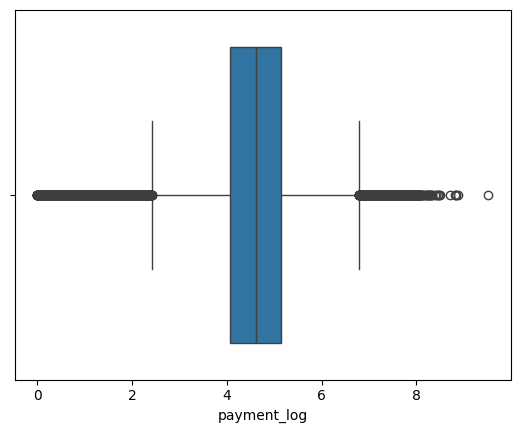

In [18]:
import numpy as np

order_payments['payment_log'] = np.log1p(
    order_payments.payment_value
)

sns.boxplot(
    x=order_payments['payment_log']
)

# sns.boxplot(
#     x=order_payments['payment_value']
# )

In [19]:
order_payments[order_payments.payment_value>5000]

,order_id,payment_sequential,payment_type,payment_installments,payment_value,payment_log
34370,736e1922ae60d0d6a89247b851902527,1,boleto,1,7274.88,8.892320
41419,0812eb902a67711a1cb742b3cdaa65ae,1,credit_card,8,6929.31,8.843660
49581,fefacc66af859508bf1a7934eab1e97f,1,boleto,1,6922.21,8.842635
52107,03caa2c082116e1d31e67e9ae3700499,1,credit_card,1,13664.08,9.522599
62409,2cc9089445046817a7539d90805e6e5a,1,boleto,1,6081.54,8.713178
85539,f5136e38d1a14a4dbd87dff67da82701,1,boleto,1,6726.66,8.813983


In [20]:
order_payments.groupby(
    'order_id'
).size().value_counts()

,count
1,96479
2,2382
3,301
4,108
5,52
6,36
7,28
8,11
9,9
11,8


In [21]:
payment_count = (
    order_payments
    .groupby('order_id')
    .size()
)

payment_count[
    payment_count>10
]

,0
order_id,
0bbb3f7791a87d0307555e57da3a1ff1,11
1a611328643ae11146ba09a4425d2e12,12
1be51feefcd481bee3118900e6777057,11
1d9a9731b9c10fc9cba74e6f74782e8b,12
21577126c19bf11a0b91592e5844ba78,15
27a940efdd448db29463b53ea0cfa2f4,11
285c2e15bebd4ac83635ccc563dc71f4,22
370e2e6c1a9fd451eb7f0852daa3b006,11
3c58bffb70dcf45f12bdf66a3c215905,14


In [22]:
weird_orders = payment_count[
    payment_count>10
].index

order_payments[
    order_payments.order_id.isin(
        weird_orders
    )
]

,order_id,payment_sequential,payment_type,payment_installments,payment_value,payment_log
679,68986e4324f6a21481df4e6e89abcf01,5,voucher,1,16.54,2.864484
987,4fb76fa13b108a0d0478483421b0992c,6,voucher,1,10.04,2.401525
1132,370e2e6c1a9fd451eb7f0852daa3b006,7,voucher,1,6.82,2.056685
1448,1d9a9731b9c10fc9cba74e6f74782e8b,6,voucher,1,8.47,2.248129
1517,1be51feefcd481bee3118900e6777057,6,voucher,1,10.05,2.402430
...,...,...,...,...,...,...
103444,465c2e1bee4561cb39e0db8c5993aafc,6,voucher,1,13.40,2.667228
103463,4069c489933782af79afcd3a0e4d693c,11,voucher,1,11.37,2.515274
103485,3c58bffb70dcf45f12bdf66a3c215905,8,voucher,1,6.20,1.974081
103569,fedcd9f7ccdc8cba3a18defedd1a5547,6,voucher,1,8.60,2.261763


In [23]:
orders['purchase_month'] = (
    orders['order_purchase_timestamp']
    .dt.to_period('M')
)

orders.groupby(
    'purchase_month'
).size()

,0
purchase_month,
2016-09,4
2016-10,324
2016-12,1
2017-01,800
2017-02,1780
2017-03,2682
2017-04,2404
2017-05,3700
2017-06,3245


In [24]:
weird_orders = payment_count[
    payment_count>10
].index

order_payments[
    order_payments.order_id.isin(
        weird_orders
    )
]

,order_id,payment_sequential,payment_type,payment_installments,payment_value,payment_log
679,68986e4324f6a21481df4e6e89abcf01,5,voucher,1,16.54,2.864484
987,4fb76fa13b108a0d0478483421b0992c,6,voucher,1,10.04,2.401525
1132,370e2e6c1a9fd451eb7f0852daa3b006,7,voucher,1,6.82,2.056685
1448,1d9a9731b9c10fc9cba74e6f74782e8b,6,voucher,1,8.47,2.248129
1517,1be51feefcd481bee3118900e6777057,6,voucher,1,10.05,2.402430
...,...,...,...,...,...,...
103444,465c2e1bee4561cb39e0db8c5993aafc,6,voucher,1,13.40,2.667228
103463,4069c489933782af79afcd3a0e4d693c,11,voucher,1,11.37,2.515274
103485,3c58bffb70dcf45f12bdf66a3c215905,8,voucher,1,6.20,1.974081
103569,fedcd9f7ccdc8cba3a18defedd1a5547,6,voucher,1,8.60,2.261763


In [25]:
orders[
    orders.delivery_days>100
][[
    'order_status',
    'order_purchase_timestamp',
    'order_delivered_customer_date'
]]

,order_status,order_purchase_timestamp,order_delivered_customer_date
1621,delivered,2018-01-17 10:50:09,2018-05-07 19:25:33
3077,delivered,2017-11-14 10:04:27,2018-02-27 18:05:08
3202,delivered,2017-04-28 16:28:03,2017-09-19 13:54:18
4666,delivered,2017-09-26 18:35:35,2018-02-05 21:25:43
10383,delivered,2018-01-31 20:38:38,2018-05-18 11:06:52
...,...,...,...
86520,delivered,2017-11-29 15:10:14,2018-05-21 18:22:18
89130,delivered,2017-03-08 22:47:40,2017-09-19 14:00:04
92212,delivered,2017-12-16 10:04:35,2018-04-28 15:51:50
95136,delivered,2017-11-25 12:14:38,2018-04-16 23:26:51


# JOIN TABLE

In [27]:
customer_orders = (
    orders.merge(
        customers,
        on='customer_id',
        how='left'
    )
)

In [28]:
customer_orders_reviews = (
    customer_orders.merge(
        order_reviews,
        on='order_id',
        how='left'
    )
)

In [29]:
payments_agg = (
    order_payments
    .groupby('order_id')
    .agg({
        'payment_value':'sum',
        'payment_installments':'max',
        'payment_sequential':'max',
        'payment_type':lambda x:x.mode()[0]
    })
    .reset_index()
)

In [30]:
master_df = (
    customer_orders_reviews
    .merge(
        payments_agg,
        on='order_id',
        how='left'
    )
)

In [31]:
items_seller = (
    order_items
    .merge(
        sellers,
        on='seller_id',
        how='left'
    )
)

In [32]:
seller_agg = (
    items_seller
    .groupby('order_id')
    .agg({
        'seller_id':'nunique',
        'seller_state':lambda x:x.mode()[0],
        'price':'sum',
        'freight_value':'sum'
    })
    .reset_index()
)

In [33]:
master_df = (
    master_df
    .merge(
        seller_agg,
        on='order_id',
        how='left'
    )
)

In [34]:
geo_clean = (
    geolocation
    .groupby('geolocation_zip_code_prefix')
    .agg({
        'geolocation_lat':'mean',
        'geolocation_lng':'mean'
    })
    .reset_index()
)

In [35]:
customers_geo = (
    customers
    .merge(
        geo_clean,
        left_on='customer_zip_code_prefix',
        right_on='geolocation_zip_code_prefix',
        how='left'
    )
)

In [36]:
print(master_df.info())
print(customers_geo.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99992 entries, 0 to 99991
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99992 non-null  object        
 1   customer_id                    99992 non-null  object        
 2   order_status                   99992 non-null  object        
 3   order_purchase_timestamp       99992 non-null  datetime64[ns]
 4   order_approved_at              99831 non-null  object        
 5   order_delivered_carrier_date   98199 non-null  object        
 6   order_delivered_customer_date  97005 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99992 non-null  object        
 8   delivery_days                  97005 non-null  float64       
 9   purchase_month                 99992 non-null  period[M]     
 10  customer_unique_id             99992 non-null  object        
 11  customer_zip_co

## Feature Engineering

# 1. DELIVERY FEATURES (CORE CX)

## A. delivery_delay_days

In [37]:
master_df['order_approved_at'] = pd.to_datetime(
    master_df['order_approved_at']
)

master_df['order_delivered_carrier_date'] = pd.to_datetime(
    master_df['order_delivered_carrier_date']
)

master_df['order_estimated_delivery_date'] = pd.to_datetime(
    master_df['order_estimated_delivery_date'
])

In [38]:
master_df['delivery_delay_days'] = (
    master_df['order_delivered_customer_date'] - master_df['order_estimated_delivery_date']
).dt.days

In [39]:
master_df['delivery_delay_days'].describe()

,delivery_delay_days
count,97005.000000
mean,-11.880790
std,10.183992
min,-147.000000
25%,-17.000000
50%,-12.000000
75%,-7.000000
max,188.000000


## B. Delivery Bucket

In [40]:
def delivery_bucket(x):
    if pd.isna(x):
        return 'Unknown'
    elif x<=0:
        return 'On Time'
    elif x<=3:
        return '1-3 Days Late'
    elif x<=7:
        return '4-7 Days Late'
    else:
        return 'Critical Delay'

master_df['delivery_bucket'] = master_df['delivery_delay_days'].apply(delivery_bucket)

In [41]:
master_df[
    'delivery_bucket'
].value_counts()

,count
delivery_bucket,
On Time,90442
Unknown,2987
Critical Delay,2879
1-3 Days Late,1874
4-7 Days Late,1810


## C. approval_delay_hours

In [42]:
master_df['approval_delay_hours'] = (
    master_df['order_approved_at']
    -
    master_df['order_purchase_timestamp']
).dt.total_seconds()/3600

# 2. CUSTOMER FEATURES

## A. purchase_count

In [43]:
purchase_count = (
    master_df
    .groupby(
        'customer_unique_id'
    )['order_id']
    .nunique()
    .reset_index()
)

In [44]:
purchase_count.columns = [
    'customer_unique_id',
    'purchase_count'
]

In [45]:
master_df = (
    master_df
    .merge(
        purchase_count,
        on='customer_unique_id',
        how='left'
    )
)

## B. repeat_customer

In [46]:
master_df[
    'repeat_customer'
] = (
    master_df['purchase_count']>1
).astype(int)

## C. avg_customer_order_value

In [47]:
customer_spend = (
    master_df
    .groupby(
        'customer_unique_id'
    )['payment_value']
    .mean()
    .reset_index()
)

In [48]:
customer_spend.columns = [
    'customer_unique_id',
    'avg_customer_order_value'
]

In [49]:
master_df = (
    master_df
    .merge(
        customer_spend,
        on='customer_unique_id',
        how='left'
    )
)

# 3. PAYMENT FEATURES

## A. high_installment_flag

In [51]:
master_df['high_installment'] = (
    master_df['payment_installments']>=6
).astype(int)

## B. multi_payment_flag

In [ ]:
master_df[
    'multi_payment'
] = (
    master_df['payment_sequential']>1
).astype(int)

## C. log_payment_value

In [53]:
master_df[
    'payment_log'
] = np.log1p(master_df['payment_value'])

# 4. SELLER PROXIMITY FEATURES

## A. same_state

core feature kita.

In [54]:
master_df[
    'same_state'
] = (
    master_df['customer_state'] == master_df['seller_state']).astype(int)

## B. freight_ratio

interesting insight.

In [55]:
master_df[
    'freight_ratio'
] = (

    master_df['freight_value']

    /

    master_df['price']

)

# 5. NLP PREP FEATURES

belum NLP modeling.

baru preparation.

## A. review_text

In [56]:
master_df[
    'review_text'
] = (
    master_df[
        'review_comment_title'
    ].fillna('')
    +
    ' '
    +
    master_df[
        'review_comment_message'
    ].fillna('')
)

## B. has_review_text

penting.

In [57]:
master_df[
    'has_review_text'
] = (
    master_df['review_text']
    .str.strip()
    !=''
).astype(int)

## C. text_length

nice analytics.

In [58]:
master_df[
    'review_length'
] = (
    master_df['review_text']
    .str.len()
)

## D. pseudo_sentiment_baseline

sementara.

buat backup kalau nanti NLP gagal.

In [59]:
def score_to_sentiment(x):

    if pd.isna(x):
        return 'Unknown'

    elif x>=4:
        return 'Positive'

    elif x==3:
        return 'Neutral'

    else:
        return 'Negative'

In [60]:
master_df[
    'score_sentiment'
] = master_df[
    'review_score'
].apply(score_to_sentiment)

# 6. GEO FEATURES

pakai tabel geo_clean.

In [61]:
master_df = (
    master_df
    .merge(
        customers_geo[[
            'customer_id',
            'geolocation_lat',
            'geolocation_lng'
        ]],
        on='customer_id',
        how='left'
    )
)

# 7. TOTAL CHECK

In [62]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99992 entries, 0 to 99991
Data columns (total 45 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99992 non-null  object        
 1   customer_id                    99992 non-null  object        
 2   order_status                   99992 non-null  object        
 3   order_purchase_timestamp       99992 non-null  datetime64[ns]
 4   order_approved_at              99831 non-null  datetime64[ns]
 5   order_delivered_carrier_date   98199 non-null  datetime64[ns]
 6   order_delivered_customer_date  97005 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99992 non-null  datetime64[ns]
 8   delivery_days                  97005 non-null  float64       
 9   purchase_month                 99992 non-null  period[M]     
 10  customer_unique_id             99992 non-null  object        
 11  customer_zip_co

In [63]:
master_df[[
    'delivery_delay_days',
    'delivery_bucket',
    'purchase_count',
    'repeat_customer',
    'payment_log',
    'same_state',
    'has_review_text'
]].head()

,delivery_delay_days,delivery_bucket,purchase_count,repeat_customer,payment_log,same_state,has_review_text
0,-8.0,On Time,2,1,3.681603,1,1
1,-6.0,On Time,1,0,4.959061,0,1
2,-18.0,On Time,1,0,5.193623,0,0
3,-13.0,On Time,1,0,4.293195,0,1
4,-10.0,On Time,1,0,3.388450,1,0


## Cek Isi Parquet

In [3]:
import os
import pandas as pd

RAW_PATH = "../data_lake/raw"

for folder in os.listdir(RAW_PATH):
    folder_path = os.path.join(
        RAW_PATH,
        folder
    )

    if not os.path.isdir(folder_path):
        continue

    files = os.listdir(folder_path)

    parquet_files = [
        f for f in files
        if f.endswith(".parquet")
    ]

    if len(parquet_files)==0:
        continue

    latest_file = parquet_files[0]

    full_path = os.path.join(
        folder_path,
        latest_file
    )

    df = pd.read_parquet(
        full_path
    )

    print("\n"+"="*70)
    print(folder.upper())
    print("="*70)

    print(
        "Shape:",
        df.shape
    )

    print(
        "Columns:",
        df.columns.tolist()
    )

    display(
        df.head(2)
    )


CUSTOMERS
Shape: (99441, 5)
Columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP



ORDER_ITEMS
Shape: (112650, 7)
Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93



ORDER_PAYMENTS
Shape: (103886, 5)
Columns: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']


...

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,None,None,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,None,None,2018-03-10 00:00:00,2018-03-11 03:05:13



ORDERS
Shape: (99441, 8)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00



SELLERS
Shape: (3095, 4)
Columns: ['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP


## Baca hasil processed spark

In [1]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("CheckProcessed")
    .getOrCreate()
)

analytics_orders = spark.read.parquet(
    "../data_lake/processed/analytics_orders"
)

customer_geo = spark.read.parquet(
    "../data_lake/processed/customer_geo"
)

seller_proximity = spark.read.parquet(
    "../data_lake/processed/seller_proximity"
)

print("analytics_orders :", analytics_orders.count())
print("customer_geo      :", customer_geo.count())
print("seller_proximity  :", seller_proximity.count())

print("\n=== analytics_orders ===")
analytics_orders.printSchema()

print("\n=== customer_geo ===")
customer_geo.printSchema()

print("\n=== seller_proximity ===")
seller_proximity.printSchema()



26/06/03 12:16:33 WARN Utils: Your hostname, Ibrahims-MacBook-Air.local resolves to a loopback address: 127.0.0.1; using 192.168.68.90 instead (on interface en0)
26/06/03 12:16:33 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/03 12:16:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


analytics_orders : 99992
customer_geo      : 99441
seller_proximity  : 113425

=== analytics_orders ===
root
 |-- customer_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: string (nullable = true)
 |-- order_delivered_carrier_date: string (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)
 |-- total_price: double (nullable = true)
 |-- total_freight: double (nullable = true)
 |-- payment_value: double (nullable = true)
 |-- payment_installments: long (nullable = true)
 |-- payment_sequential: long (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- review_id: string (nullable = true)
 |-- review_score: long (nullable = true)
 |-- review_comment_title: string (nullable = true)
 |-- review_comment_message: string (nullable = true)
 |--

In [2]:
analytics_orders.show(5, truncate=False)

customer_geo.show(5, truncate=False)

seller_proximity.show(5, truncate=False)

+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+-----------+-------------+-------------+--------------------+------------------+------------+--------------------------------+------------+--------------------+---------------------------------------------------------------------------------------------------------------------------+--------------------+-----------------------+--------------------------------+------------------------+--------------+--------------+
|customer_id                     |order_id                        |order_status|order_purchase_timestamp|order_approved_at  |order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|total_price|total_freight|payment_value|payment_installments|payment_sequential|payment_type|review_id                       |review_score|review_comment_

In [3]:
analytics_orders.select(
    "order_id"
).distinct().count()

analytics_orders.count()

99992

In [4]:
from pyspark.sql.functions import col, count, when

analytics_orders.select([
    count(
        when(col(c).isNull(), c)
    ).alias(c)

    for c in analytics_orders.columns
]).show(vertical=True)

customer_geo.select([
    count(
        when(col(c).isNull(), c)
    ).alias(c)

    for c in customer_geo.columns
]).show(vertical=True)

seller_proximity.select([
    count(
        when(col(c).isNull(), c)
    ).alias(c)

    for c in seller_proximity.columns
]).show(vertical=True)

-RECORD 0------------------------------
 customer_id                   | 0     
 order_id                      | 0     
 order_status                  | 0     
 order_purchase_timestamp      | 0     
 order_approved_at             | 161   
 order_delivered_carrier_date  | 1793  
 order_delivered_customer_date | 2987  
 order_estimated_delivery_date | 0     
 total_price                   | 778   
 total_freight                 | 778   
 payment_value                 | 0     
 payment_installments          | 1     
 payment_sequential            | 1     
 payment_type                  | 1     
 review_id                     | 768   
 review_score                  | 0     
 review_comment_title          | 88424 
 review_comment_message        | 59015 
 review_creation_date          | 768   
 review_answer_timestamp       | 768   
 customer_unique_id            | 0     
 customer_zip_code_prefix      | 0     
 customer_city                 | 0     
 customer_state                | 0     


In [5]:
seller_proximity.groupBy(
    "same_state"
).count().show()

+----------+-----+
|same_state|count|
+----------+-----+
|         1|40756|
|         0|72669|
+----------+-----+



In [6]:
analytics_orders.select(
    "total_price",
    "total_freight",
    "payment_value"
).describe().show()

seller_proximity.select(
    "price",
    "freight_value"
).describe().show()

+-------+------------------+------------------+------------------+
|summary|       total_price|     total_freight|     payment_value|
+-------+------------------+------------------+------------------+
|  count|             99214|             99214|             99992|
|   mean|137.60077680568838| 22.81884461870334|160.82707356588585|
| stddev|210.28462247564772|21.624221732337613|221.57957647505933|
|    min|              0.85|               0.0|               0.0|
|    max|           13440.0|1794.9600000000003|          13664.08|
+-------+------------------+------------------+------------------+

+-------+------------------+------------------+
|summary|             price|     freight_value|
+-------+------------------+------------------+
|  count|            112650|            112650|
|   mean|120.65373901477244|19.990319928985777|
| stddev|183.63392805025813|15.806405412297076|
|    min|              0.85|               0.0|
|    max|            6735.0|            409.68|
+-------+---

In [10]:
analytics_orders.filter(
    analytics_orders["total_price"].isNull()
).groupBy(
    "order_status"
).count().show()

+------------+-----+
|order_status|count|
+------------+-----+
|    canceled|  165|
| unavailable|  605|
|     created|    5|
|     shipped|    1|
|    invoiced|    2|
+------------+-----+



## CEK HASIL FEATURE ENGINEERING

### Delivery

In [5]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("CheckDeliveryFeatures")
    .getOrCreate()
)

delivery_df = spark.read.parquet(
    "../data_lake/features/delivery_features"
)

print(
    "Total rows:",
    delivery_df.count()
)

delivery_df.printSchema()



Total rows: 99992
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- review_score: long (nullable = true)
 |-- actual_delivery_days: integer (nullable = true)
 |-- delivery_delay_days: integer (nullable = true)
 |-- delay_bucket: string (nullable = true)
 |-- purchase_month: string (nullable = true)
 |-- cancellation_flag: integer (nullable = true)
 |-- purchase_count_per_customer: long (nullable = true)
 |-- repeat_customer: integer (nullable = true)



26/06/05 14:14:21 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


### Payments


In [6]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("CheckPaymentFeatures")
    .getOrCreate()
)

payment_df = spark.read.parquet(
    "../data_lake/features/payment_features"
)

print("Rows:", payment_df.count())

payment_df.printSchema()

payment_df.show(5, truncate=False)

Rows: 99440
root
 |-- order_id: string (nullable = true)
 |-- payment_count_per_order: long (nullable = true)
 |-- payment_value: double (nullable = true)
 |-- payment_installments: long (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- multi_payment_flag: integer (nullable = true)
 |-- installment_group: string (nullable = true)
 |-- high_value_payment_flag: integer (nullable = true)

+--------------------------------+-----------------------+-------------+--------------------+------------+------------------+-----------------+-----------------------+
|order_id                        |payment_count_per_order|payment_value|payment_installments|payment_type|multi_payment_flag|installment_group|high_value_payment_flag|
+--------------------------------+-----------------------+-------------+--------------------+------------+------------------+-----------------+-----------------------+
|00010242fe8c5a6d1ba2dd792cb16214|1                      |72.19        |2                 

26/06/05 14:14:55 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [4]:
payment_df.select(
    "payment_count_per_order",
    "multi_payment_flag",
    "installment_group",
    "high_value_payment_flag"
).show(20, truncate=False)

+-----------------------+------------------+-----------------+-----------------------+
|payment_count_per_order|multi_payment_flag|installment_group|high_value_payment_flag|
+-----------------------+------------------+-----------------+-----------------------+
|1                      |0                 |2-6              |0                      |
|1                      |0                 |1                |0                      |
|1                      |0                 |2-6              |1                      |
|1                      |0                 |2-6              |0                      |
|1                      |0                 |1                |0                      |
|1                      |0                 |2-6              |0                      |
|1                      |0                 |1                |0                      |
|1                      |0                 |2-6              |0                      |
|1                      |0                 

In [5]:
payment_df.groupBy(
    "installment_group"
).count().show()

+-----------------+-----+
|installment_group|count|
+-----------------+-----+
|             7-12|11988|
|              12+|  187|
|                1|48268|
|              2-6|38997|
+-----------------+-----+



In [6]:
payment_df.groupBy(
    "multi_payment_flag"
).count().show()

+------------------+-----+
|multi_payment_flag|count|
+------------------+-----+
|                 1| 2961|
|                 0|96479|
+------------------+-----+



In [7]:
payment_df.groupBy(
    "high_value_payment_flag"
).count().show()

+-----------------------+-----+
|high_value_payment_flag|count|
+-----------------------+-----+
|                      1| 5893|
|                      0|93547|
+-----------------------+-----+



### NLP (REVIEW TEXT)

In [8]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("CheckNLPFeatures")
    .getOrCreate()
)

nlp_df = spark.read.parquet(
    "../data_lake/features/nlp_features"
)

26/06/05 14:15:29 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [23]:
print(
    "Rows:",
    nlp_df.count()
)

Rows: 99992


In [9]:
nlp_df.printSchema()

root
 |-- order_id: string (nullable = true)
 |-- review_score: long (nullable = true)
 |-- review_comment_message: string (nullable = true)
 |-- review_text_clean: string (nullable = true)
 |-- has_text: integer (nullable = true)
 |-- complaint_topic: string (nullable = true)



In [25]:
nlp_df.select(
    "review_score",
    "review_comment_message",
    "review_text_clean",
    "has_text",
    "complaint_topic"
).show(
    20,
    truncate=False
)

+------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------+--------+---------------+
|review_score|review_comment_message                                                                                                                                                  |review_text_clean                                                                                                                                                      |has_text|complaint_topic|
+------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------------------------------------------------------------

In [26]:
nlp_df.groupBy(
    "has_text"
).count().show()

+--------+-----+
|has_text|count|
+--------+-----+
|       1|40827|
|       0|59165|
+--------+-----+



In [29]:
nlp_df.groupBy(
    "complaint_topic"
).count().orderBy(
    "count",
    ascending=False
).show(
    50,
    truncate=False
)

+--------------------+-----+
|complaint_topic     |count|
+--------------------+-----+
|other               |74558|
|delivery            |20905|
|seller_communication|1868 |
|refund              |972  |
|damaged_product     |814  |
|packaging           |622  |
|product_issue       |253  |
+--------------------+-----+



In [14]:
nlp_df.filter(
    nlp_df["has_text"] == 0
).select(
    "review_score",
    "review_comment_message"
).show(
    20,
    truncate=False
)

+------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|review_score|review_comment_message                                                                                                                                                                                  |
+------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|4           |👏👏👏👏👏                                                                                                                                                                                              |
|4           |...............................................................................................................................

In [15]:
nlp_df.filter(
    nlp_df["complaint_topic"] == "delivery"
).select(
    "review_text_clean"
).show(
    20,
    truncate=False
)

+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|review_text_clean                                                                                                                                                            |
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|muito eficiente recebi antes do prazo                                                                                                                                        |
|comorei 4 vidros de vitamina d3 paguei um frete caro e só recebi 3 vidros quero receber o quarto que tudo custou r 260 00                                                    |
|não recebi o produto                                                                                                   

In [18]:
nlp_df.filter(
    nlp_df["complaint_topic"] == "packaging"
).select(
    "review_text_clean"
).show(
    20,
    truncate=False
)

+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|review_text_clean                                                                                                                                                                                |
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|o produto é de péssima qualidade a furacão não se encaixa com a do veículo e olha que o para barro corresponde ao modelo do carro o plástico é ruim é gual ao de pote de margarina               |
|não recomendo produto não funcionou e veio numa embalagem sem proteção                                                                                                                           |
|adorei o cuidado co

In [ ]:
nlp_df.filter(
    nlp_df["complaint_topic"] == "seller_communication"
).select(
    "review_text_clean"
).show(
    20,
    truncate=False
)

+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|review_text_clean                                                                                                                                                                                      |
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|difícil comunicação com o vendedor após a compra do produto foram duas tentativas de compra a primeira resultou inexitosa e foi cancelada sem explicação ainda aguardo pela segunda compra do mesmo    |
|não consegue falar com o vendedor quando tem problemas não tem numero de telefone para entrar em contato um lixo                                                                               

In [20]:
nlp_df.filter(
    nlp_df["complaint_topic"] == "refund"
).select(
    "review_text_clean"
).show(
    20,
    truncate=False
)

+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|review_text_clean                                                                                                                                                                          |
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|comprei uma marca e veio outro bem inferior já pedi p devolver estou aguardando                                                                                                            |
|veio faltando não era o que eu queria quero devolver                                                                                                                                       |
|o relógio que veio com uma falha no vidro mal aco

In [21]:
nlp_df.filter(
    nlp_df["complaint_topic"] == "damaged_product"
).select(
    "review_text_clean"
).show(
    20,
    truncate=False
)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|review_text_clean                                                                                                                                                                                  |
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|amei o kit chegou com 8 dias q eu tinha pedido muito bom não faltou nenhum e veio sem nenhum defeito                                                                                               |
|o relógio veio com defeito como faço pra trocar                                                                                                                                                    |
|relógio v

In [ ]:
nlp_df.filter(
    nlp_df["complaint_topic"] == "other"
).select(
    "review_text_clean"
).show(
    50,
    truncate=False
)

+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|review_text_clean                                                                                                                                                                                 |
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|produto excelente fiquei muito satisfeito                                                                                                                                                         |
|produto bom equivalente ao valor                                                                                                                                                                  |
|muito bom     

In [17]:
nlp_df.groupBy(
    "complaint_topic"
).agg(
    {"review_score":"avg"}
).show(
    truncate=False
)

+--------------------+------------------+
|complaint_topic     |avg(review_score) |
+--------------------+------------------+
|seller_communication|3.5286298568507157|
|other               |4.189538431012674 |
|damaged_product     |1.9863636363636363|
|refund              |1.7259259259259259|
|packaging           |2.778810408921933 |
|delivery            |3.581795889771135 |
+--------------------+------------------+



### Customer Segmentations

In [10]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("CheckCustomerFeatures")
    .getOrCreate()
)

customer_df = spark.read.parquet(
    "../data_lake/features/customer_features"
)

print(
    "Rows:",
    customer_df.count()
)

customer_df.printSchema()

Rows: 93358
root
 |-- customer_unique_id: string (nullable = true)
 |-- frequency: long (nullable = true)
 |-- monetary: double (nullable = true)
 |-- avg_order_value: double (nullable = true)
 |-- first_purchase_date: timestamp (nullable = true)
 |-- last_purchase_date: timestamp (nullable = true)
 |-- avg_review_score: double (nullable = true)
 |-- preferred_payment_type: string (nullable = true)
 |-- recency_days: integer (nullable = true)
 |-- customer_tenure_days: integer (nullable = true)
 |-- repeat_customer: integer (nullable = true)



26/06/05 14:15:56 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [71]:
customer_df.show(
    10,
    truncate=False
)

+--------------------------------+---------+--------+---------------+-------------------+-------------------+----------------+----------------------+------------+--------------------+---------------+
|customer_unique_id              |frequency|monetary|avg_order_value|first_purchase_date|last_purchase_date |avg_review_score|preferred_payment_type|recency_days|customer_tenure_days|repeat_customer|
+--------------------------------+---------+--------+---------------+-------------------+-------------------+----------------+----------------------+------------+--------------------+---------------+
|0000b849f77a49e4a4ce2b2a4ca5be3f|1        |27.19   |27.19          |2018-05-07 11:11:27|2018-05-07 11:11:27|4.0             |credit_card           |114         |0                   |0              |
|0000f6ccb0745a6a4b88665a16c9f078|1        |43.62   |43.62          |2017-10-12 20:29:41|2017-10-12 20:29:41|4.0             |credit_card           |321         |0                   |0              |


In [72]:
from pyspark.sql import functions as F

customer_df.select(
    "customer_unique_id",
    "frequency"
).orderBy(
    F.desc("frequency")
).show(20, False)

+--------------------------------+---------+
|customer_unique_id              |frequency|
+--------------------------------+---------+
|8d50f5eadf50201ccdcedfb9e2ac8455|15       |
|3e43e6105506432c953e165fb2acf44c|9        |
|1b6c7548a2a1f9037c1fd3ddfed95f33|7        |
|ca77025e7201e3b30c44b472ff346268|7        |
|6469f99c1f9dfae7733b25662e7f1782|7        |
|47c1a3033b8b77b3ab6e109eb4d5fdf3|6        |
|63cfc61cee11cbe306bff5857d00bfe4|6        |
|f0e310a6839dce9de1638e0fe5ab282a|6        |
|12f5d6e1cbf93dafd9dcc19095df0b3d|6        |
|dc813062e0fc23409cd255f7f53c7074|6        |
|35ecdf6858edc6427223b64804cf028e|5        |
|de34b16117594161a6a89c50b289d35a|5        |
|394ac4de8f3acb14253c177f0e15bc58|5        |
|56c8638e7c058b98aae6d74d2dd6ea23|5        |
|b4e4f24de1e8725b74e4a1f4975116ed|5        |
|74cb1ad7e6d5674325c1f99b5ea30d82|5        |
|fe81bb32c243a86b2f86fbf053fe6140|5        |
|5e8f38a9a1c023f3db718edcf926a2db|5        |
|4e65032f1f574189fb793bac5a867bbc|5        |
|730543071

In [74]:
customer_df.select(

    "frequency",

    "monetary",

    "avg_order_value",

    "avg_review_score",

    "recency_days",

    "customer_tenure_days"

).describe().show()

+-------+-------------------+------------------+------------------+-----------------+------------------+--------------------+
|summary|          frequency|          monetary|   avg_order_value| avg_review_score|      recency_days|customer_tenure_days|
+-------+-------------------+------------------+------------------+-----------------+------------------+--------------------+
|  count|              93358|             93358|             93358|            93358|             93358|               93358|
|   mean| 1.0334197390689603|165.94564568649685|160.32105810309648| 4.12620694292699|237.47887701107564|   2.645086655669573|
| stddev|0.20909743968188577|227.80867954231277|219.58129242623636|1.318992863021418|152.59505429572323|  25.007424864682207|
|    min|                  1|               0.0|               0.0|              0.0|                 0|                   0|
|    max|                 15|          13664.08|          13664.08|              5.0|               713|              

In [53]:
customer_df.orderBy(
    "total_orders",
    ascending=False
).show(
    10,
    truncate=False
)

+--------------------------------+------------+------------------+------------------+-------------------+-------------------+------------------+----------------------+------------+--------------------+---------------+
|customer_unique_id              |total_orders|total_spent       |avg_order_value   |first_purchase_date|last_purchase_date |avg_review_score  |preferred_payment_type|recency_days|customer_tenure_days|repeat_customer|
+--------------------------------+------------+------------------+------------------+-------------------+-------------------+------------------+----------------------+------------+--------------------+---------------+
|8d50f5eadf50201ccdcedfb9e2ac8455|15          |879.27            |58.618            |2017-06-18 22:56:48|2018-08-20 19:14:26|5.0               |credit_card           |9           |428                 |1              |
|3e43e6105506432c953e165fb2acf44c|9           |1172.66           |130.29555555555555|2017-09-18 18:53:15|2018-02-27 18:36:39|2.7

In [55]:
customer_df.orderBy(
    "total_spent",
    ascending=False
).show(
    10,
    truncate=False
)

+--------------------------------+------------+-----------+---------------+-------------------+-------------------+----------------+----------------------+------------+--------------------+---------------+
|customer_unique_id              |total_orders|total_spent|avg_order_value|first_purchase_date|last_purchase_date |avg_review_score|preferred_payment_type|recency_days|customer_tenure_days|repeat_customer|
+--------------------------------+------------+-----------+---------------+-------------------+-------------------+----------------+----------------------+------------+--------------------+---------------+
|0a0a92112bd4c708ca5fde585afaa872|1           |13664.08   |13664.08       |2017-09-29 15:24:52|2017-09-29 15:24:52|1.0             |credit_card           |334         |0                   |0              |
|da122df9eeddfedc1dc1f5349a1a690c|2           |7571.63    |3785.815       |2017-04-01 15:58:40|2017-04-01 15:58:41|5.0             |credit_card           |515         |0       

In [56]:
customer_df.orderBy(
    "recency_days"
).show(
    10,
    truncate=False
)

+--------------------------------+------------+-----------+---------------+-------------------+-------------------+----------------+----------------------+------------+--------------------+---------------+
|customer_unique_id              |total_orders|total_spent|avg_order_value|first_purchase_date|last_purchase_date |avg_review_score|preferred_payment_type|recency_days|customer_tenure_days|repeat_customer|
+--------------------------------+------------+-----------+---------------+-------------------+-------------------+----------------+----------------------+------------+--------------------+---------------+
|afbcfd0b9c5233e7ccc73428526fbb52|1           |497.25     |497.25         |2018-08-29 08:46:11|2018-08-29 08:46:11|5.0             |credit_card           |0           |0                   |0              |
|24ac2b4327e25baf39f2119e4228976a|1           |93.75      |93.75          |2018-08-29 15:00:37|2018-08-29 15:00:37|5.0             |credit_card           |0           |0       

In [75]:
from pyspark.sql import functions as F

customer_df.select([
    F.count(
        F.when(
            F.col(c).isNull(),
            c
        )
    ).alias(c)

    for c in customer_df.columns
]).show(
    truncate=False
)

+------------------+---------+--------+---------------+-------------------+------------------+----------------+----------------------+------------+--------------------+---------------+
|customer_unique_id|frequency|monetary|avg_order_value|first_purchase_date|last_purchase_date|avg_review_score|preferred_payment_type|recency_days|customer_tenure_days|repeat_customer|
+------------------+---------+--------+---------------+-------------------+------------------+----------------+----------------------+------------+--------------------+---------------+
|0                 |0        |0       |0              |0                  |0                 |0               |0                     |0           |0                   |0              |
+------------------+---------+--------+---------------+-------------------+------------------+----------------+----------------------+------------+--------------------+---------------+



In [60]:
customer_df.groupBy(
    "repeat_customer"
).count().show()

+---------------+-----+
|repeat_customer|count|
+---------------+-----+
|              1| 2801|
|              0|90557|
+---------------+-----+



### Geo

In [11]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("CheckCustomerGeo")
    .getOrCreate()
)

geo_df = spark.read.parquet(
    "../data_lake/processed/customer_geo"
)

print("Rows:", geo_df.count())

geo_df.printSchema()

geo_df.show(5, truncate=False)

Rows: 99441
root
 |-- customer_id: string (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_zip_code_prefix: long (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- geolocation_lat: double (nullable = true)
 |-- geolocation_lng: double (nullable = true)

+--------------------------------+--------------------------------+------------------------+---------------------+--------------+-------------------+-------------------+
|customer_id                     |customer_unique_id              |customer_zip_code_prefix|customer_city        |customer_state|geolocation_lat    |geolocation_lng    |
+--------------------------------+--------------------------------+------------------------+---------------------+--------------+-------------------+-------------------+
|06b8999e2fba1a1fbc88172c00ba8bc7|861eff4711a542e4b93843c6dd7febb0|14409                   |franca               |SP            |-20.4984887

26/06/05 14:16:45 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [77]:
from pyspark.sql import functions as F

geo_df.select([
    F.count(
        F.when(
            F.col(c).isNull(),
            c
        )
    ).alias(c)

    for c in geo_df.columns
]).show(truncate=False)

+-----------+------------------+------------------------+-------------+--------------+---------------+---------------+
|customer_id|customer_unique_id|customer_zip_code_prefix|customer_city|customer_state|geolocation_lat|geolocation_lng|
+-----------+------------------+------------------------+-------------+--------------+---------------+---------------+
|0          |0                 |0                       |0            |0             |278            |278            |
+-----------+------------------+------------------------+-------------+--------------+---------------+---------------+



In [78]:
geo_df.select(
    "customer_unique_id"
).distinct().count()

96096

In [79]:
geo_df.groupBy(
    "customer_state"
).count().orderBy(
    F.desc("count")
).show(50, False)

+--------------+-----+
|customer_state|count|
+--------------+-----+
|SP            |41746|
|RJ            |12852|
|MG            |11635|
|RS            |5466 |
|PR            |5045 |
|SC            |3637 |
|BA            |3380 |
|DF            |2140 |
|ES            |2033 |
|GO            |2020 |
|PE            |1652 |
|CE            |1336 |
|PA            |975  |
|MT            |907  |
|MA            |747  |
|MS            |715  |
|PB            |536  |
|PI            |495  |
|RN            |485  |
|AL            |413  |
|SE            |350  |
|TO            |280  |
|RO            |253  |
|AM            |148  |
|AC            |81   |
|AP            |68   |
|RR            |46   |
+--------------+-----+



In [80]:
geo_df.groupBy(
    "customer_city"
).count().orderBy(
    F.desc("count")
).show(20, False)

+---------------------+-----+
|customer_city        |count|
+---------------------+-----+
|sao paulo            |15540|
|rio de janeiro       |6882 |
|belo horizonte       |2773 |
|brasilia             |2131 |
|curitiba             |1521 |
|campinas             |1444 |
|porto alegre         |1379 |
|salvador             |1245 |
|guarulhos            |1189 |
|sao bernardo do campo|938  |
|niteroi              |849  |
|santo andre          |797  |
|osasco               |746  |
|santos               |713  |
|goiania              |692  |
|sao jose dos campos  |691  |
|fortaleza            |654  |
|sorocaba             |633  |
|recife               |613  |
|florianopolis        |570  |
+---------------------+-----+
only showing top 20 rows



In [81]:
geo_df.filter(
    F.col("geolocation_lat").isNull()
).show(
    20,
    truncate=False
)

+--------------------------------+--------------------------------+------------------------+---------------------------+--------------+---------------+---------------+
|customer_id                     |customer_unique_id              |customer_zip_code_prefix|customer_city              |customer_state|geolocation_lat|geolocation_lng|
+--------------------------------+--------------------------------+------------------------+---------------------------+--------------+---------------+---------------+
|ecb1725b26e8b8c458181455dfa434ea|b55a113bb84fc10eaf58c6d09ec69794|72300                   |brasilia                   |DF            |NULL           |NULL           |
|bcf86029aeed4ed8bac0e16eb14c22f5|7cd7974c9f79f75b77f323878ef87f43|11547                   |cubatao                    |SP            |NULL           |NULL           |
|f4302056f0c58570522590f8181de2c7|67b05b597a66b5c449025000b9430abb|64605                   |picos                      |PI            |NULL           |NULL     

In [82]:
geo_df.select(
    F.min("geolocation_lat"),
    F.max("geolocation_lat"),
    F.min("geolocation_lng"),
    F.max("geolocation_lng")
).show()

+--------------------+--------------------+--------------------+--------------------+
|min(geolocation_lat)|max(geolocation_lat)|min(geolocation_lng)|max(geolocation_lng)|
+--------------------+--------------------+--------------------+--------------------+
| -33.689948281745096|   42.18400274298598|  -72.66888054135308|  -8.723762147513938|
+--------------------+--------------------+--------------------+--------------------+



In [83]:
geo_df.printSchema()

geo_df.select([
    F.count(
        F.when(
            F.col(c).isNull(),
            c
        )
    ).alias(c)

    for c in geo_df.columns
]).show(truncate=False)

geo_df.groupBy(
    "customer_state"
).count().orderBy(
    F.desc("count")
).show(20, False)

root
 |-- customer_id: string (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_zip_code_prefix: long (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- geolocation_lat: double (nullable = true)
 |-- geolocation_lng: double (nullable = true)

+-----------+------------------+------------------------+-------------+--------------+---------------+---------------+
|customer_id|customer_unique_id|customer_zip_code_prefix|customer_city|customer_state|geolocation_lat|geolocation_lng|
+-----------+------------------+------------------------+-------------+--------------+---------------+---------------+
|0          |0                 |0                       |0            |0             |278            |278            |
+-----------+------------------+------------------------+-------------+--------------+---------------+---------------+

+--------------+-----+
|customer_state|count|
+--------------+----

### Seller

In [12]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("CheckSellerFeatures")
    .getOrCreate()
)

seller_df = spark.read.parquet(
    "../data_lake/features/seller_features"
)

print(
    "Rows:",
    seller_df.count()
)

seller_df.printSchema()

Rows: 113425
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- seller_state: string (nullable = true)
 |-- same_state: integer (nullable = true)
 |-- interstate_order: integer (nullable = true)
 |-- seller_count_per_order: long (nullable = true)
 |-- multi_seller_order_flag: integer (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)
 |-- freight_ratio: double (nullable = true)
 |-- high_freight_flag: integer (nullable = true)
 |-- freight_bucket: string (nullable = true)



26/06/05 14:17:40 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [3]:
seller_df.show(
    20,
    truncate=False
)

+--------------------------------+--------------------------------+--------------------------------+--------------+------------+----------+----------------+------+-------------+-------------+-----------------+--------------+
|order_id                        |customer_id                     |seller_id                       |customer_state|seller_state|same_state|interstate_order|price |freight_value|freight_ratio|high_freight_flag|freight_bucket|
+--------------------------------+--------------------------------+--------------------------------+--------------+------------+----------+----------------+------+-------------+-------------+-----------------+--------------+
|e481f51cbdc54678b7cc49136f2d6af7|9ef432eb6251297304e76186b10a928d|3504c0cb71d7fa48d967e0e4c94d59d9|SP            |SP          |1         |0               |29.99 |8.72         |0.2908       |0                |Medium        |
|53cdb2fc8bc7dce0b6741e2150273451|b0830fb4747a6c6d20dea0b8c802d7ef|289cdb325fb7e7f891c38608bf9e0962|

In [12]:
from pyspark.sql import functions as F

seller_df.select([
    F.count(
        F.when(
            F.col(c).isNull(),
            c
        )
    ).alias(c)

    for c in seller_df.columns
]).show(
    truncate=False
)

+--------+-----------+---------+--------------+------------+----------+----------------+----------------------+-----------------------+-----+-------------+-------------+-----------------+--------------+
|order_id|customer_id|seller_id|customer_state|seller_state|same_state|interstate_order|seller_count_per_order|multi_seller_order_flag|price|freight_value|freight_ratio|high_freight_flag|freight_bucket|
+--------+-----------+---------+--------------+------------+----------+----------------+----------------------+-----------------------+-----+-------------+-------------+-----------------+--------------+
|0       |0          |775      |0             |775         |0         |0               |0                     |0                      |775  |775          |775          |0                |0             |
+--------+-----------+---------+--------------+------------+----------+----------------+----------------------+-----------------------+-----+-------------+-------------+-----------------+-

In [5]:
seller_df.groupBy(
    "same_state"
).count().show()

+----------+-----+
|same_state|count|
+----------+-----+
|         1|40756|
|         0|72669|
+----------+-----+



In [6]:
seller_df.groupBy(
    "interstate_order"
).count().show()

+----------------+-----+
|interstate_order|count|
+----------------+-----+
|               1|72669|
|               0|40756|
+----------------+-----+



In [13]:
seller_df.groupBy(
    "freight_bucket"
).count().show()

+--------------+-----+
|freight_bucket|count|
+--------------+-----+
|          High|41960|
|           Low|17524|
|        Medium|53941|
+--------------+-----+



In [14]:
seller_df.groupBy(
    "same_state"
).agg(
    F.avg(
        "freight_ratio"
    ).alias(
        "avg_freight_ratio"
    )
).show()

+----------+-------------------+
|same_state|  avg_freight_ratio|
+----------+-------------------+
|         1|0.25149514918048377|
|         0|0.36018749408851114|
+----------+-------------------+



In [9]:
seller_df.orderBy(
    "freight_ratio",
    ascending=False
).show(
    20,
    truncate=False
)

+--------------------------------+--------------------------------+--------------------------------+--------------+------------+----------+----------------+-----+-------------+-------------+-----------------+--------------+
|order_id                        |customer_id                     |seller_id                       |customer_state|seller_state|same_state|interstate_order|price|freight_value|freight_ratio|high_freight_flag|freight_bucket|
+--------------------------------+--------------------------------+--------------------------------+--------------+------------+----------+----------------+-----+-------------+-------------+-----------------+--------------+
|c5bdd8ef3c0ec420232e668302179113|5af78bf1a82a2660d1e3fd78c645f58f|96804ea39d96eb908e7c3afdb671bb9e|SP            |MG          |0         |1               |0.85 |22.3         |26.2353      |1                |High          |
|3ee6513ae7ea23bdfab5b9ab60bffcb5|161b6d415e8b3413c6609c70cf405b5a|96804ea39d96eb908e7c3afdb671bb9e|SP  

In [10]:
seller_df.groupBy(
    "order_id"
).count().orderBy(
    F.desc("count")
).show(20)

+--------------------+-----+
|            order_id|count|
+--------------------+-----+
|8272b63d03f5f79c5...|   21|
|1b15974a0141d54e3...|   20|
|ab14fdcfbe524636d...|   20|
|428a2f660dc84138d...|   15|
|9ef13efd6949e4573...|   15|
|73c8ab38f07dc9438...|   14|
|9bdc4d4c71aa1de46...|   14|
|37ee401157a3a0b28...|   13|
|2c2a19b5703863c90...|   12|
|af822dacd6f5cff73...|   12|
|c05d6a79e55da72ca...|   12|
|3a213fcdfe7d98be7...|   12|
|637617b3ffe9e2f7a...|   12|
|71dab1155600756af...|   11|
|5a3b1c29a49756e75...|   11|
|7f2c22c54cbae5509...|   11|
|6c355e2913545fa6f...|   11|
|9aec4e1ae90b23c7b...|   10|
|30bdf3d824d824610...|   10|
|ca3625898fbd48669...|   10|
+--------------------+-----+
only showing top 20 rows



### CX

In [3]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder
    .appName("CheckCX")
    .getOrCreate()
)

cx_df = spark.read.parquet(
    "../data_lake/features/cx_features"
)

26/06/05 13:55:53 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [ ]:
cx_df.printSchema()

root
 |-- customer_unique_id: string (nullable = true)
 |-- avg_review_score: double (nullable = true)
 |-- avg_delivery_penalty_days: double (nullable = true)
 |-- late_delivery_rate: double (nullable = true)
 |-- complaint_rate: double (nullable = true)
 |-- frequency: long (nullable = true)
 |-- monetary: double (nullable = true)
 |-- recency_days: integer (nullable = true)
 |-- customer_tenure_days: integer (nullable = true)
 |-- repeat_customer: integer (nullable = true)
 |-- review_component: double (nullable = true)
 |-- delivery_component: double (nullable = true)
 |-- complaint_component: double (nullable = true)
 |-- frequency_score: double (nullable = true)
 |-- tenure_score: double (nullable = true)
 |-- recency_score: double (nullable = true)
 |-- loyalty_component: double (nullable = true)
 |-- cx_score: double (nullable = true)
 |-- cx_category: string (nullable = true)



26/06/05 16:30:25 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 680939 ms exceeds timeout 120000 ms
26/06/05 16:30:25 WARN SparkContext: Killing executors is not supported by current scheduler.
26/06/05 16:30:26 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:80)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:642)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1223)
	at o

In [19]:
cx_df.groupBy(
    "cx_category"
).count().show()

+-----------+-----+
|cx_category|count|
+-----------+-----+
|  Excellent|42997|
|       Good|32290|
|       Fair| 9497|
|       Poor| 8574|
+-----------+-----+



In [20]:
cx_df.select(
    "cx_score"
).describe().show()

+-------+------------------+
|summary|          cx_score|
+-------+------------------+
|  count|             93358|
|   mean|  80.2537889202409|
| stddev|17.130714902538326|
|    min|              19.5|
|    max| 99.99999999999999|
+-------+------------------+



In [21]:
cx_df.select(
    "frequency_score",
    "tenure_score",
    "recency_score",
    "loyalty_component"
).describe().show()

+-------+-------------------+-------------------+-------------------+-------------------+
|summary|    frequency_score|       tenure_score|      recency_score|  loyalty_component|
+-------+-------------------+-------------------+-------------------+-------------------+
|  count|              93358|              93358|              93358|              93358|
|   mean|0.31273377750177317|0.21030441954616869|  0.492030677606611|0.31786435013599734|
| stddev|0.07378539614762798|0.07897871713561522|0.23524806978834634|0.07498983539777833|
|    min|                0.3|                0.2|                0.2|               0.25|
|    max|                1.0|                1.0|                1.0|                1.0|
+-------+-------------------+-------------------+-------------------+-------------------+



In [22]:
cx_df.orderBy(
    F.desc("cx_score")
).select(
    "customer_unique_id",
    "cx_score",
    "avg_review_score",
    "frequency",
    "complaint_rate",
    "avg_delivery_penalty_days"
).show(
    20,
    False
)

+--------------------------------+-----------------+----------------+---------+--------------+-------------------------+
|customer_unique_id              |cx_score         |avg_review_score|frequency|complaint_rate|avg_delivery_penalty_days|
+--------------------------------+-----------------+----------------+---------+--------------+-------------------------+
|394ac4de8f3acb14253c177f0e15bc58|99.99999999999999|5.0             |5        |0.0           |0.0                      |
|1b6e96ed99cb8d135efe220d761bbd67|99.99999999999999|5.0             |3        |0.0           |0.0                      |
|e53fd5575f1418397aae732c5755b6fc|99.99999999999999|5.0             |3        |0.0           |0.0                      |
|8f6ce2295bdbec03cd50e34b4bd7ba0a|99.99999999999999|5.0             |3        |0.0           |0.0                      |
|a73c5464692d3bc09d64e3edefae9015|99.6             |5.0             |4        |0.0           |0.0                      |
|3ea4185126195c34ed9949d8e406d57

In [7]:
cx_df.orderBy(
    "cx_score"
).select(
    "customer_unique_id",
    "cx_score",
    "avg_review_score",
    "frequency",
    "complaint_rate",
    "avg_delivery_penalty_days"
).show(
    20,
    False
)

+--------------------------------+--------+----------------+---------+--------------+-------------------------+
|customer_unique_id              |cx_score|avg_review_score|frequency|complaint_rate|avg_delivery_penalty_days|
+--------------------------------+--------+----------------+---------+--------------+-------------------------+
|52c68003c255391fe1409b1fb084fe54|19.5    |1.0             |1        |1.0           |35.0                     |
|15ccaaaa2289afed8a5e40273330c13d|19.5    |1.0             |1        |1.0           |16.0                     |
|286c51fe0bc2f07fed3594a58acf77f4|19.5    |1.0             |1        |1.0           |8.0                      |
|2e3c051a9f6e30c8e6d7d45feb4be118|19.5    |1.0             |1        |1.0           |13.0                     |
|7b627f49e4baf01fba4645b2a681a356|19.5    |1.0             |1        |1.0           |10.0                     |
|d69e7376cd254c900729616e75624e12|19.5    |1.0             |1        |1.0           |19.0               

In [23]:
cx_df.groupBy(
    "frequency"
).count().orderBy(
    "frequency"
).show(20)

+---------+-----+
|frequency|count|
+---------+-----+
|        1|90557|
|        2| 2573|
|        3|  181|
|        4|   28|
|        5|    9|
|        6|    5|
|        7|    3|
|        9|    1|
|       15|    1|
+---------+-----+



In [25]:
cx_df.groupBy(
    "frequency_score"
).count().show()

+---------------+-----+
|frequency_score|count|
+---------------+-----+
|            0.7| 2573|
|            1.0|  228|
|            0.3|90557|
+---------------+-----+



In [24]:
cx_df.groupBy(
    "frequency"
).count().orderBy(
    F.desc("count")
).show(20)

+---------+-----+
|frequency|count|
+---------+-----+
|        1|90557|
|        2| 2573|
|        3|  181|
|        4|   28|
|        5|    9|
|        6|    5|
|        7|    3|
|        9|    1|
|       15|    1|
+---------+-----+



In [26]:
cx_df.groupBy(
    "repeat_customer"
).count().show()

+---------------+-----+
|repeat_customer|count|
+---------------+-----+
|              1| 2801|
|              0|90557|
+---------------+-----+



In [12]:
cx_df.filter(
    F.col("frequency").isNull()
).count()

2738

In [28]:
cx_df.filter(
    F.col("frequency").isNull()
).select(
    "customer_unique_id",
    "avg_review_score",
    "avg_delivery_penalty_days",
    "complaint_rate"
).show(
    20,
    False
)

+------------------+----------------+-------------------------+--------------+
|customer_unique_id|avg_review_score|avg_delivery_penalty_days|complaint_rate|
+------------------+----------------+-------------------------+--------------+
+------------------+----------------+-------------------------+--------------+



In [ ]:
customer_df = spark.read.parquet(
    "../data_lake/features/customer_features"
)

print(
    customer_df.select(
        "customer_unique_id"
    ).distinct().count()
)

93358


26/06/05 12:55:58 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 1924345 ms exceeds timeout 120000 ms
26/06/05 12:55:58 WARN SparkContext: Killing executors is not supported by current scheduler.
26/06/05 12:55:58 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:80)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:642)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1223)
	at 

In [27]:
cx_df.groupBy(
    "cx_category"
).count().show()

+-----------+-----+
|cx_category|count|
+-----------+-----+
|  Excellent|42997|
|       Good|32290|
|       Fair| 9497|
|       Poor| 8574|
+-----------+-----+



In [ ]:
import os

for folder in os.listdir("../data_lake/features"):
    print(folder)

payment_features
.DS_Store
customer_features
seller_features
cx_features
nlp_features
delivery_features


26/06/05 13:50:16 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:80)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:642)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1223)
	at org.apache.spark.executor.Executor.$anonfun$heartbeater$1(Executor.scala:295)
	at scala.runtime.java8.JFunction0$mcV$sp.apply(JFunction0$mcV$sp.java:23)
	at org.apache.spark.util.Utils$.logUncaughtExceptions(Utils.scala:1928)

In [31]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

for table in [
    "customer_features",
    "delivery_features",
    "seller_features",
    "payment_features",
    "nlp_features",
    "cx_features"
]:
    df = spark.read.parquet(
        f"../data_lake/features/{table}"
    )

    print(
        table,
        df.count()
    )

customer_features 93358
delivery_features 99992
seller_features 113425
payment_features 99440
nlp_features 99992
cx_features 93358


26/06/05 13:51:36 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE

In [4]:
payment_df.select(
    F.countDistinct("order_id")
).show()

+------------------------+
|count(DISTINCT order_id)|
+------------------------+
|                   99440|
+------------------------+

